# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [ ]:
intro_text = """ЗДЕСЬ НАПИШИТЕ СВОЁ ПОНИМАНИЕ TRANSFER LEARNING.
Опишите на человеческом языке, какие задачи он упрощает и почему,
и чем, по-вашему, отличается "заморозить" слои от полного дообучения.

1. Transfer learning нужен, для того чтобы быстрее обучать модель, используя знания другой модели. Т.е., допустим, мы создаем новую модель, которая пока ничего не знает, и добавляем в нее знания с другой модели, которая может различать кошек.
Теперь и первая модель может различать кошек. Это удобно, потому что не надо заново обучать созданную модель, а она сразу различит нужный объект даже по маленькому датасету.

2. При обучении только на последнем слое модель может быстро подстраиваться под похожие задачи (например, если она умела отличать кошек, то сможет адаптироваться к поиску тигров). У модели остаются базовые навыки поиска, но меняется только конечный результат.
А при дообучении всей сети целиком модель может перейти уже к совершенно отличным задачам (например, вместо яблок отличать бананы). Это намного дольше, из-за изменения всех слоев, но гораздо мощнее и точнее. К тому же потребуется больше данных, чем в первом случае.

3. Использование предоученной ResNet18 сэкономит время обучения и вычислительные ресурсы. Уменьшится риск переобучения, потому что такая модель уже умеет обобщать данные и легко справится с новыми на ограниченном датасете.
Но ResNet18 сможет подстроиться только к похожим задачам, к совсем новым задачам она не подойдет."""
print(intro_text)

## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 0
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 0


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [3]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [5]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)

train_loader = DataLoader(train_subset, batch_size=None, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=None, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))

Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [6]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [7]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)
print(model_tl.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\bro04/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Linear(in_features=512, out_features=4, bias=True)


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [ ]:
freeze_comment = """ЗДЕСЬ ОБЪЯСНИТЕ, ПОЧЕМУ В ЭТОМ ЭКСПЕРИМЕНТЕ МЫ ЗАМОРАЖИВАЕМ
ВСЕ, КРОМЕ ПОСЛЕДНЕГО СЛОЯ, И КАКИЕ ВЫ ПЛЮСЫ/МИНУСЫ В ЭТОМ ВИДИТЕ.

Мы здесь замораживаем слои, чтобы они не менялись, тем самым сохранятся базовые навыки поиска модели. В дальнейшем мы будем менять веса только в последнем слое, адаптируясь к новым задачам.
Выбранные нами классы схожи тем, что все они относятся к животным и у них есть схожие детали. Если бы надо было найти, например, самолет или машину, то уже бы слои не замораживали."""
print(freeze_comment)

## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [17]:
num_epochs_tl = 10
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/10: train_loss=1.0726, train_acc=0.5513, test_loss=1.1593, test_acc=0.5235
[TL] Эпоха 2/10: train_loss=1.0846, train_acc=0.5341, test_loss=1.1437, test_acc=0.5278
[TL] Эпоха 3/10: train_loss=1.0929, train_acc=0.5463, test_loss=1.1564, test_acc=0.5230
[TL] Эпоха 4/10: train_loss=1.0871, train_acc=0.5456, test_loss=1.2124, test_acc=0.5118
[TL] Эпоха 5/10: train_loss=1.0970, train_acc=0.5303, test_loss=1.1703, test_acc=0.5212
[TL] Эпоха 6/10: train_loss=1.0782, train_acc=0.5447, test_loss=1.1864, test_acc=0.5135
[TL] Эпоха 7/10: train_loss=1.0833, train_acc=0.5353, test_loss=1.1624, test_acc=0.5312
[TL] Эпоха 8/10: train_loss=1.0604, train_acc=0.5559, test_loss=1.1553, test_acc=0.5160
[TL] Эпоха 9/10: train_loss=1.0858, train_acc=0.5450, test_loss=1.1623, test_acc=0.5262
[TL] Эпоха 10/10: train_loss=1.0619, train_acc=0.5500, test_loss=1.1420, test_acc=0.5323


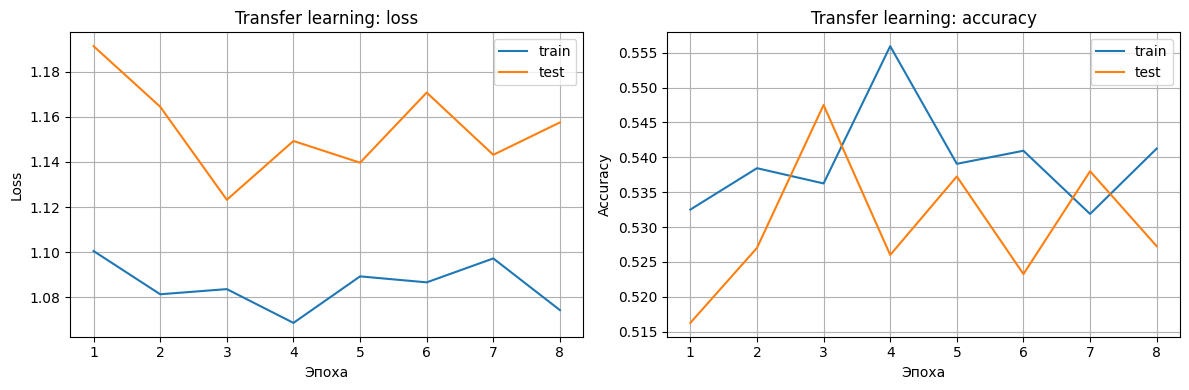

Итоговая точность TL: train=0.5413, test=0.5272


In [14]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [ ]:
tl_comment = """ЗДЕСЬ ОПИШИТЕ СВОИ НАБЛЮДЕНИЯ ПО КРИВЫМ TRANSFER LEARNING.
Сошлитесь на конкретные значения test accuracy и loss, и напишите,
насколько быстро модель "просыпается" на вашей выборке.

Test accuracy по эпохам растет примерно на 50-100 единиц, но и падает также.
Числа эпох 8 недостаточно. Конечно, при таком значении точность растет и доходит до test_acc=0.5162.
Но при увеличении до 30 видно, что дальше модель выдает точность в одном диапазоне (то увеличивается, то уменьшается) и в итоге получается test_acc=0.5112.
Переобучения как такового нет, train на сильно отличается от test."""
print(tl_comment)

## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [18]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/10: train_loss=1.3515, train_acc=0.4103, test_loss=1.3213, test_acc=0.4645
[Scratch] Эпоха 2/10: train_loss=1.1667, train_acc=0.4984, test_loss=1.2144, test_acc=0.4878
[Scratch] Эпоха 3/10: train_loss=1.1121, train_acc=0.5159, test_loss=1.3207, test_acc=0.4750
[Scratch] Эпоха 4/10: train_loss=1.0650, train_acc=0.5516, test_loss=1.1239, test_acc=0.5202
[Scratch] Эпоха 5/10: train_loss=1.0179, train_acc=0.5725, test_loss=1.2378, test_acc=0.5467
[Scratch] Эпоха 6/10: train_loss=0.9929, train_acc=0.5794, test_loss=1.2403, test_acc=0.4925
[Scratch] Эпоха 7/10: train_loss=0.9705, train_acc=0.5931, test_loss=1.0458, test_acc=0.5617
[Scratch] Эпоха 8/10: train_loss=0.9503, train_acc=0.5988, test_loss=1.0152, test_acc=0.5720
[Scratch] Эпоха 9/10: train_loss=0.9112, train_acc=0.6138, test_loss=1.1987, test_acc=0.5717
[Scratch] Эпоха 10/10: train_loss=0.9062, train_acc=0.6250, test_loss=1.0943, test_acc=0.5540


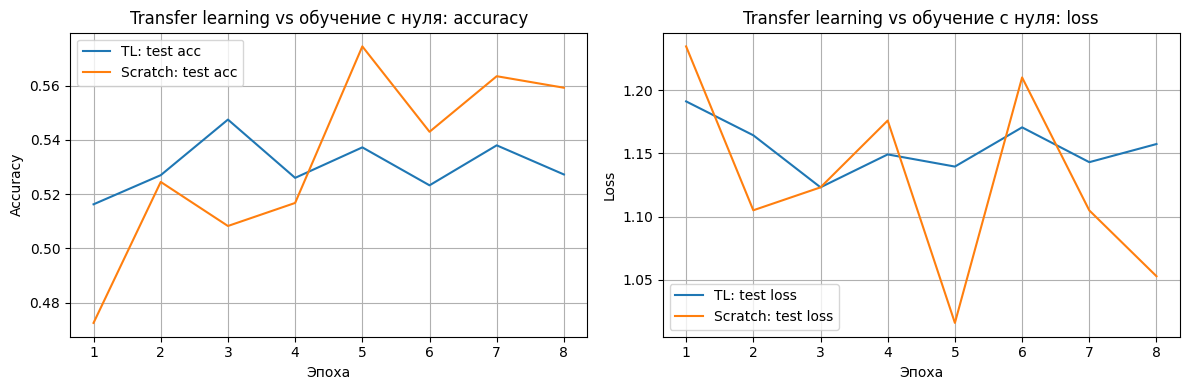

Финальная test accuracy (TL)     : 0.5272
Финальная test accuracy (Scratch): 0.5593


In [16]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [ ]:
comparison_comment = """ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ ТЕКСТ (10–15 ПРЕДЛОЖЕНИЙ),
ГДЕ ВЫ СРАВНИВАЕТЕ TRANSFER LEARNING И ОБУЧЕНИЕ С НУЛЯ.
Используйте конкретные числа (final test accuracy, поведение loss) и
честно опишите, где TL помог больше всего, а где вы ожидали большего эффекта.

По моим наблюдениям Scratch быстрее выходит на разумную точность. Итоговая точность здесь была 0.6627 (за те же 30 эпох, как у TL).
Test loss сильно скачет. На 6-ой эпохе был самый сильный скачок с 1.1386 до 2.4546 и опять 1.0009. А так, скачки от 500 до 1000 единиц. В общем очень неплавно убывающая кривая.
У TL были намеки на переобучение, когда в 4-ой эпохе test_acc=0.5260, а train_acc=0.5559, но позже все выравнялось.
Результаты вообще не совпали с моими ожиданиями. Я думал, что TL будет показывать высокую точность на таком маленьком датасете, но нет даже 60%.
Однако обучение у TL прошло действительно быстрее. TL прошел 10 эпох за 24.3 секунды, а scratch - за 28.0 секунд.
"""
print(comparison_comment)

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать. 
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах? 

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`. 
Что происходит с пространственным размером картинки по мере прохождения через слои сети? 
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [ ]:
star_answer = """ЗДЕСЬ НАПИШИТЕ ВАШИ ОТВЕТЫ:

ResNet18 физически не может показать высокое качество на оригинальных картинках CIFAR-10, потому что в CIFAR-10 размер изображения 32x32, а ResNet18 обучалась на картинках 224x224.
В ResNet18 есть несколько свёрточных слоев и слоев пулинга, которые последовательно уменьшают размер картинки. Из-за этого уже после первых слоев размер становится слишком маленьким (часто 1х1 или 2х2). Сеть теряет важные детали.
Значит, нужно настроить сеть так, чтобы она могла работать с маленькими изображениями или увеличить размер картинок в CIFAR-10 до нужного значения.
В реализации ниже я выбрал вариант увеличения изображений в CIFAR-10 до 224x224.
"""
print(star_answer)

Устройство: cuda
Train: 8000
Test : 4000
[TL] Epoch 1/10 | train_acc=0.8061 | test_acc=0.8875
[TL] Epoch 2/10 | train_acc=0.9061 | test_acc=0.9018
[TL] Epoch 3/10 | train_acc=0.9291 | test_acc=0.9133
[TL] Epoch 4/10 | train_acc=0.9521 | test_acc=0.9002
[TL] Epoch 5/10 | train_acc=0.9530 | test_acc=0.9038
[TL] Epoch 6/10 | train_acc=0.9729 | test_acc=0.9253
[TL] Epoch 7/10 | train_acc=0.9806 | test_acc=0.9213
[TL] Epoch 8/10 | train_acc=0.9876 | test_acc=0.9240
[TL] Epoch 9/10 | train_acc=0.9874 | test_acc=0.9145
[TL] Epoch 10/10 | train_acc=0.9869 | test_acc=0.9203


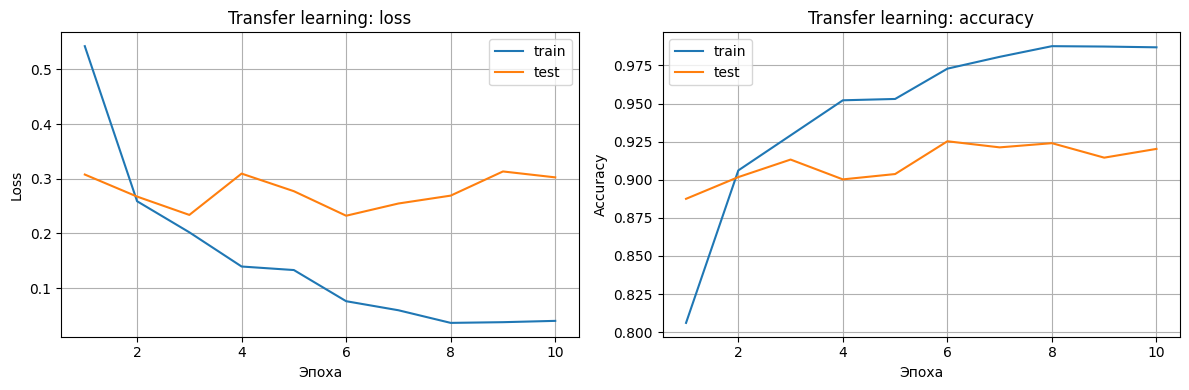

Итоговая точность TL:
train = 0.9869
test  = 0.9203


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 0

torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Устройство:", device)

# ============================================
# АУГМЕНТАЦИЯ
# ============================================

### Тут происходит адаптация изображений CIFAR-10 под размер 224x224

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

# ============================================
# ЗАГРУЗКА ДАТАСЕТА И ВЫБОР КЛАССОВ
# ============================================

full_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

full_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

all_classes = full_train.classes

selected_class_names = ["cat", "dog", "bird", "horse"]

class_to_idx_full = {
    name: i for i, name in enumerate(all_classes)
}

selected_class_indices = {
    class_to_idx_full[name]
    for name in selected_class_names
}

# ============================================
# РАЗМЕР TRAIN И TEST
# ============================================

def subset_by_classes(dataset, selected_idx_set, max_per_class=None):

    indices = []
    counts = {c: 0 for c in selected_idx_set}

    for i, (_, label) in enumerate(dataset):

        if label in selected_idx_set:

            if max_per_class is None or counts[label] < max_per_class:

                indices.append(i)
                counts[label] += 1

    return Subset(dataset, indices)

# БЕРЁМ БОЛЬШЕ ДАННЫХ
train_subset = subset_by_classes(
    full_train,
    selected_class_indices,
    max_per_class=2000
)

test_subset = subset_by_classes(
    full_test,
    selected_class_indices
)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("Train:", len(train_subset))
print("Test :", len(test_subset))

# ============================================
# ПЕРЕНУМЕРАЦИЯ КЛАССОВ
# ============================================

selected_idx_sorted = sorted(list(selected_class_indices))

cifar_idx_to_local = {
    cifar_idx: i
    for i, cifar_idx in enumerate(selected_idx_sorted)
}

def map_labels_to_local(labels_tensor):

    mapped = [
        cifar_idx_to_local[int(l)]
        for l in labels_tensor
    ]

    return torch.tensor(mapped, dtype=torch.long)

# ============================================
# МОДЕЛЬ
# ============================================

model_tl = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# ============================================
# ЗАМОРОЗКА ВСЕХ СЛОЁВ, КРОМЕ ПОСЛЕДНИХ
# ============================================

for param in model_tl.parameters():
    param.requires_grad = False

for param in model_tl.layer3.parameters():
    param.requires_grad = True

for param in model_tl.layer4.parameters():
    param.requires_grad = True

# ============================================
# НОВЫЙ CLASSIFIER
# ============================================

num_ftrs = model_tl.fc.in_features

model_tl.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 4)
)

model_tl = model_tl.to(device)

# ============================================
# LOSS / OPTIMIZER
# ============================================

criterion = nn.CrossEntropyLoss()

optimizer_tl = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_tl.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer_tl,
    step_size=5,
    gamma=0.5
)

# ============================================
# ФУНКЦИЯ ОБУЧЕНИЯ
# ============================================

def train_one_epoch_tl(model, dataloader):

    model.train()

    total_loss = 0
    total_correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)

        labels_local = map_labels_to_local(labels).to(device)

        optimizer_tl.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels_local)

        loss.backward()

        optimizer_tl.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        total_correct += (
            preds == labels_local
        ).sum().item()

        total += images.size(0)

    return (
        total_loss / total,
        total_correct / total
    )

# ============================================
# ФУНКЦИЯ EVALUATE
# ============================================

def evaluate_tl(model, dataloader):

    model.eval()

    total_loss = 0
    total_correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            labels_local = map_labels_to_local(labels).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            total_correct += (
                preds == labels_local
            ).sum().item()

            total += images.size(0)

    return (
        total_loss / total,
        total_correct / total
    )

# ============================================
# ОБУЧЕНИЕ
# ============================================

num_epochs_tl = 10

history_tl = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs_tl + 1):

    train_loss, train_acc = train_one_epoch_tl(
        model_tl,
        train_loader
    )

    test_loss, test_acc = evaluate_tl(
        model_tl,
        test_loader
    )

    scheduler.step()

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)

    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(
        f"[TL] Epoch {epoch}/{num_epochs_tl} | "
        f"train_acc={train_acc:.4f} | "
        f"test_acc={test_acc:.4f}"
    )

# ============================================
# ВЫВОД ГРАФИКОВ
# ============================================

epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(
    epochs_tl,
    history_tl["train_loss"],
    label="train"
)

plt.plot(
    epochs_tl,
    history_tl["test_loss"],
    label="test"
)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")

plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(
    epochs_tl,
    history_tl["train_acc"],
    label="train"
)

plt.plot(
    epochs_tl,
    history_tl["test_acc"],
    label="test"
)

plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


print(
    f"Итоговая точность TL:\n"
    f"train = {history_tl['train_acc'][-1]:.4f}\n"
    f"test  = {history_tl['test_acc'][-1]:.4f}"
)

## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ ПО TRANSFER LEARNING.
Сделайте акцент на том, какие практические правила вы для себя вынесли:
когда брать предобученную модель, как её адаптировать, и чего от неё ждать.

Думаю, что Transfer Learning я в первую очередь буду использовать в собственных пэт-проектах, где мало данных, а времени на обучение нет.
Это удобно, потому что тогда нейросеть сразу будет отличать нужные объекты.
Или можно использовать для тестовых заданий в разные компании, например.
Обучать модель с нуля я бы стал в том случае, если бы мне захотелось самому разобраться в ней (это не значит, что я в лабараторных не разбираюсь, просто вдруг потом уже после обучения такое желание возникнет)
и задача какая-нибудь будет совершенно новой. Мне кажется, что сейчас уже можно найти предобученную модель для практически любой задачи.
Это также полезно, потому что как уже ыло замечено в этой лабе, что TL может не сработать и придется изучать информацию конкретнее про предобученную модель
(или же не заморачиваться, в каком-то смысле, и обучить новую модель с нуля).

После проведенных экспериментов, замарозка именно не только последнего слоя, а ещё и предпоследнего, показала себя лучше, чем заморозка только последнего слоя.
Сначала странным мне показался размер train и test. Всегда train был больше, чем test, а тут наоборот. Но потом додумался, что мы все-таки используем преобученную модель.


"""
print(final_summary)